In [2]:
import glob
import os
import random
import numpy as np
import pandas as pd

root_path = "BreaKHis_v1/histology_slides/breast" # MacOS compatible path, may not work on Windows without modification

# Get the main path of the dataset



In [3]:
import bk_tools

# Get the data table and print its info and head

df = bk_tools.prepare_data_table(rootpath=root_path)

df.info()

df.head()

DataFrame shape: (7909, 8)
DataFrame columns: Index(['patient_id', 'file_id', 'example', 'class', 'year', 'zoom',
       'file_path', 'is_malign'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 7909 entries, 0 to 7908
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   patient_id  7909 non-null   str  
 1   file_id     7909 non-null   str  
 2   example     7909 non-null   str  
 3   class       7909 non-null   str  
 4   year        7909 non-null   int64
 5   zoom        7909 non-null   int64
 6   file_path   7909 non-null   str  
 7   is_malign   7909 non-null   int64
dtypes: int64(3), str(5)
memory usage: 494.4 KB


,patient_id,file_id,example,class,year,zoom,file_path,is_malign
0,13418DE,009,SOB,MC,2014,100,BreaKHis_v1/histology_slides/breast/malignant/...,1
1,13418DE,008,SOB,MC,2014,100,BreaKHis_v1/histology_slides/breast/malignant/...,1
2,13418DE,003,SOB,MC,2014,100,BreaKHis_v1/histology_slides/breast/malignant/...,1
3,13418DE,002,SOB,MC,2014,100,BreaKHis_v1/histology_slides/breast/malignant/...,1
4,13418DE,014,SOB,MC,2014,100,BreaKHis_v1/histology_slides/breast/malignant/...,1


In [4]:
df.describe()
# Check the details of numeric columns

,year,zoom,is_malign
count,7909.000000,7909.000000,7909.000000
mean,2014.008218,179.352636,0.686433
std,0.090288,133.676035,0.463972
min,2014.000000,40.000000,0.000000
25%,2014.000000,40.000000,0.000000
50%,2014.000000,100.000000,1.000000
75%,2014.000000,200.000000,1.000000
max,2015.000000,400.000000,1.000000


In [5]:
train_df_200, val_df_200, test_df_200 = bk_tools.prepare_data_splitting(df=df, chosen_zoom=200, test_val_size=0.2)
train_df_200.info()
# Split the dataset into training, validation, and test sets for the 200x zoom level


Patient split check:
64 8 9
set()
set()
set()
<class 'pandas.DataFrame'>
RangeIndex: 1628 entries, 0 to 1627
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   patient_id  1628 non-null   str  
 1   file_id     1628 non-null   str  
 2   example     1628 non-null   str  
 3   class       1628 non-null   str  
 4   year        1628 non-null   int64
 5   zoom        1628 non-null   int64
 6   file_path   1628 non-null   str  
 7   is_malign   1628 non-null   int64
dtypes: int64(3), str(5)
memory usage: 101.9 KB


In [6]:
concat_df_200 = pd.concat([train_df_200, val_df_200, test_df_200], ignore_index=True)

total_dataset = concat_df_200[["is_malign","patient_id"]].groupby("patient_id").mean()
# patients which their images are all benign or all malignant

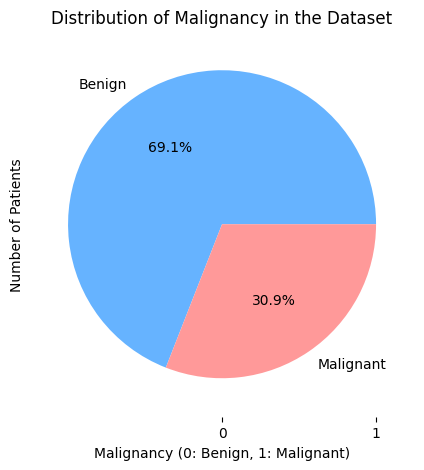

In [7]:
# Distribution of malignancy in the dataset
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.pie(concat_df_200["is_malign"].value_counts(), labels=["Benign", "Malignant"], autopct="%1.1f%%", colors=["#66b3ff", "#ff9999"])
plt.title("Distribution of Malignancy in the Dataset")
plt.xlabel("Malignancy (0: Benign, 1: Malignant)")
plt.ylabel("Number of Patients")
plt.xticks([0, 1])
plt.grid(axis="y", alpha=0.75)
plt.show()

In [8]:
# Average number of images per patient
avg_images_per_patient = concat_df_200.groupby("patient_id").size().mean()
print(f"Average number of images per patient: {avg_images_per_patient:.2f}")

Average number of images per patient: 24.85


In [20]:
def show_class_samples_by_zoom(dataframe, selected_zoom, n_cols=4, random_sample=False):
    zoom_df = dataframe[dataframe["zoom"] == selected_zoom].copy()

    if zoom_df.empty:
        print(f"No data found for zoom={selected_zoom}")
        return

    if random_sample:
        sample_per_class = zoom_df.sample(frac=1).reset_index(drop=True)
    else:
        sample_per_class = zoom_df.groupby("class", as_index=False).first()

    classes = sorted(sample_per_class["class"].unique())
    n_classes = len(classes)
    n_rows = int(np.ceil(n_classes / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, cls in enumerate(classes):
        ax = axes[i]
        row = sample_per_class[sample_per_class["class"] == cls].iloc[0]
        image_path = row["file_path"]

        if os.path.isfile(image_path):
            img = plt.imread(image_path)
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, f"Missing file\n{cls}", ha="center", va="center")

        ax.set_title(f"Class: {cls}")
        ax.axis("off")

    for j in range(n_classes, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"One sample per class at {selected_zoom}x zoom", y=1.02)
    plt.tight_layout()
    plt.show()

In [21]:
df["class"].unique()

<StringArray>
['MC', 'PC', 'DC', 'LC', 'A', 'TA', 'F', 'PT']
Length: 8, dtype: str

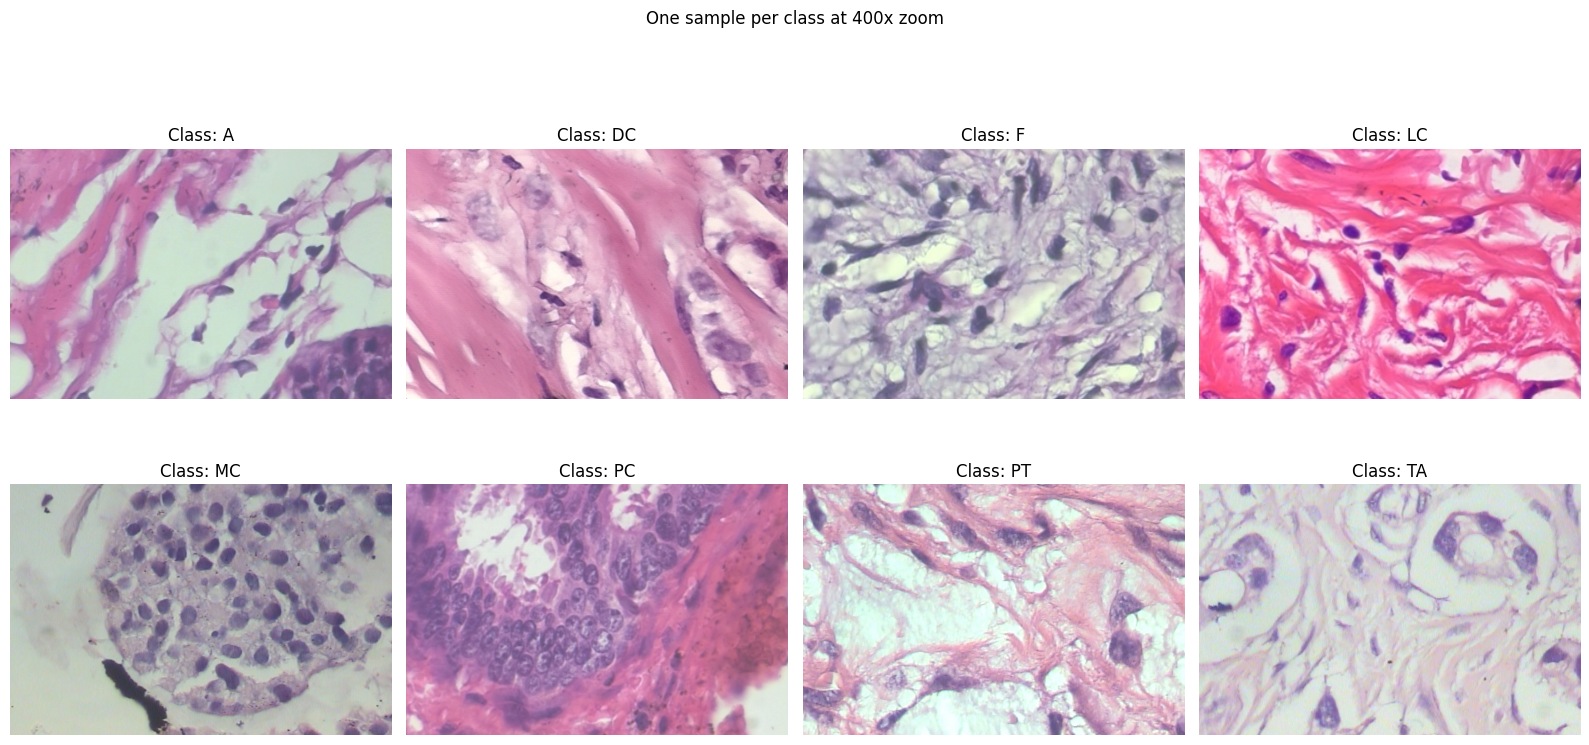

In [31]:
show_class_samples_by_zoom(df, 400, n_cols=4, random_sample=True)